In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
from scipy.stats import bootstrap

In [2]:
DP = DP()
all_df, _, _, _ = DP.extract_fits_data('./catalogs/0315_all_test.fits')
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0315_dps_test.fits')

In [3]:
print(len(all_df))
print(len(dps_df))

57271
25671


In [4]:
delta_dv = dps_df['DV_R'] - dps_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['SIGMA_L']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
# dps_df['width_ratio'] = sigma_l / sigma_r
dps_df['width_ratio'] = dps_df['SIGMA_L'] / dps_df['SIGMA_R']


In [5]:
delta_dv = all_df['DV_R'] - all_df['DV_L']
resolution = c * 0.8 / (Halpha_rest*(1+all_df['Z']))
sigma_r = np.sqrt(all_df['SIGMA_R']**2 + resolution**2)
sigma_l = np.sqrt(all_df['SIGMA_L']**2 + resolution**2)
all_df['delta_dv'] = delta_dv
# all_df['width_ratio'] = sigma_l / sigma_r
all_df['width_ratio'] = all_df['SIGMA_L'] / all_df['SIGMA_R']


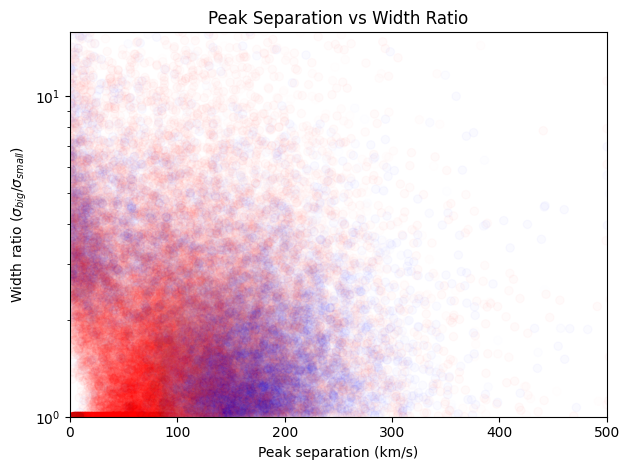

In [22]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(all_df['delta_dv'], 10**np.abs(np.log10(all_df['width_ratio'])), alpha=0.02, c=np.log10(all_df['P_VALUE']), cmap='bwr')
plt.xlim(left=0, right=500)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
plt.title('Peak Separation vs Width Ratio')
plt.tight_layout()
plt.savefig('./figures/Mar26/peak_sep_width_ratio.png')
plt.show()

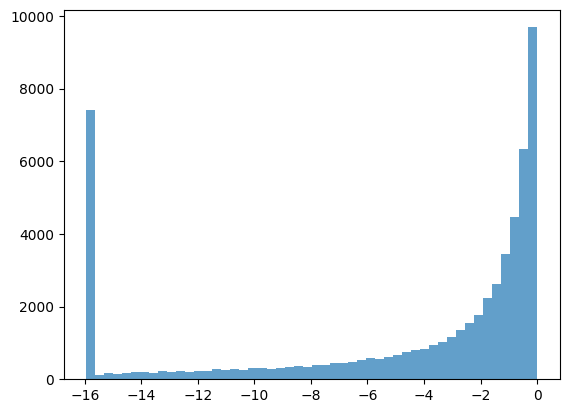

In [7]:
plt.hist(np.log10(all_df['P_VALUE']), bins=50, alpha=0.7)
plt.show()

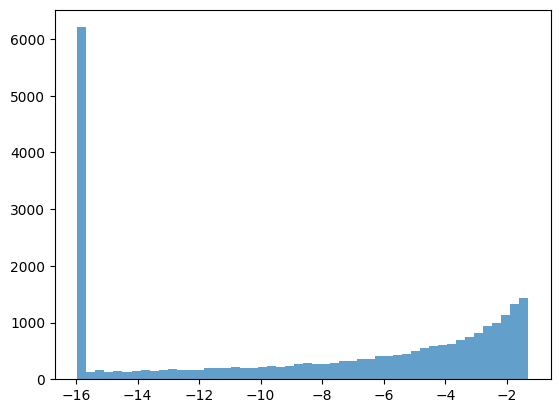

In [8]:
plt.hist(np.log10(dps_df['P_VALUE']), bins=50, alpha=0.7)
plt.show()

In [9]:
print(len(all_df[all_df['P_VALUE']<1e-8]))
print(len(all_df[(all_df['P_VALUE']>1e-8)&(all_df['P_VALUE']<5e-2)]))
print(len(all_df[all_df['P_VALUE']>5e-2]))

13199
19908
24164


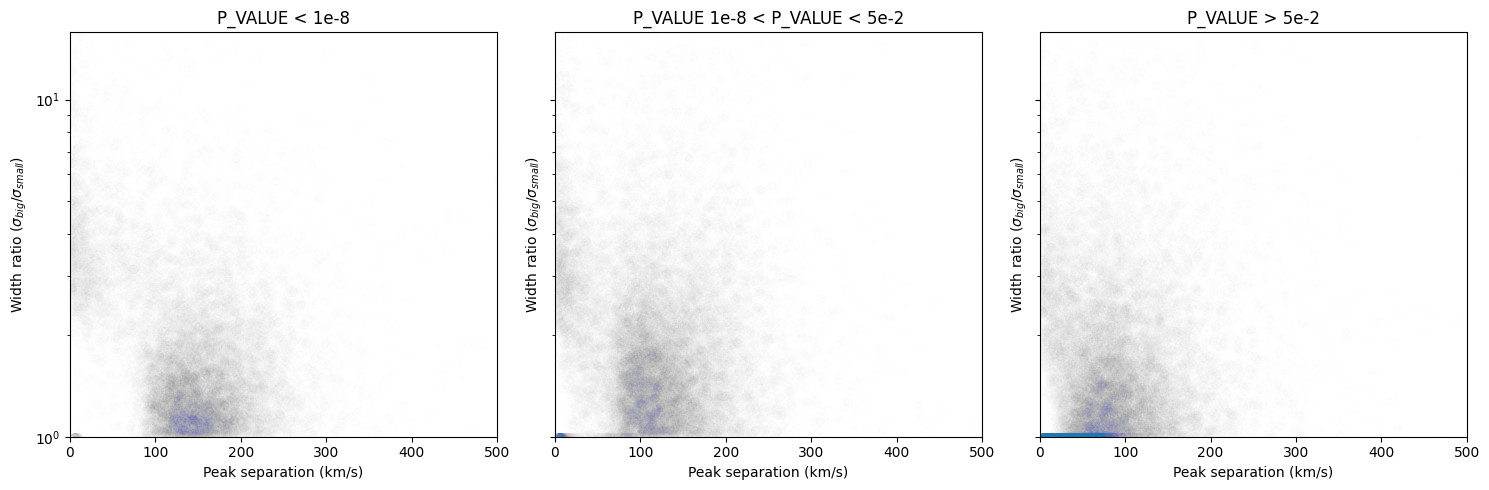

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i, df in enumerate([all_df[all_df['P_VALUE']<1e-8], all_df[(all_df['P_VALUE']>1e-8)&(all_df['P_VALUE']<5e-2)], all_df[all_df['P_VALUE']>5e-2]]):
    ax[i].scatter(df['delta_dv'], 10**np.abs(np.log10(df['width_ratio'])), alpha=0.005)
    ax[i].set_xlim(left=0, right=500)
    ax[i].set_ylim(bottom=1, top=10**1.2)
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Peak separation (km/s)')
    ax[i].set_ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
    ax[i].set_title(f'P_VALUE {["< 1e-8", "1e-8 < P_VALUE < 5e-2", "> 5e-2"][i]}')
plt.tight_layout()
plt.show()

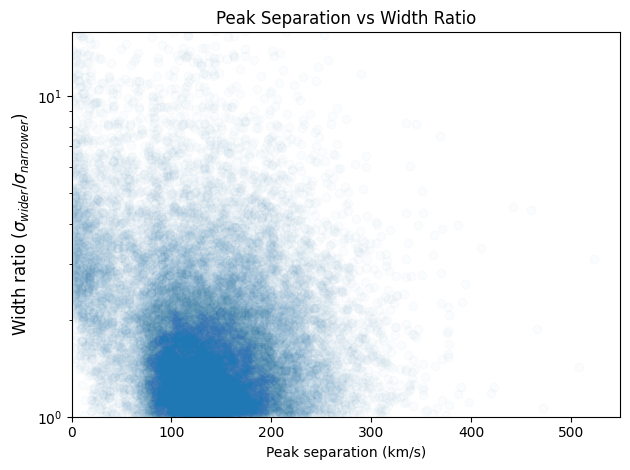

In [11]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], 10**np.abs(np.log10(dps_df['width_ratio'])), alpha=0.02)
plt.xlim(left=0)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Width ratio ($\sigma_{wider}/\sigma_{narrower}$)', fontsize=12)
plt.title('Peak Separation vs Width Ratio')
plt.tight_layout()
plt.show()

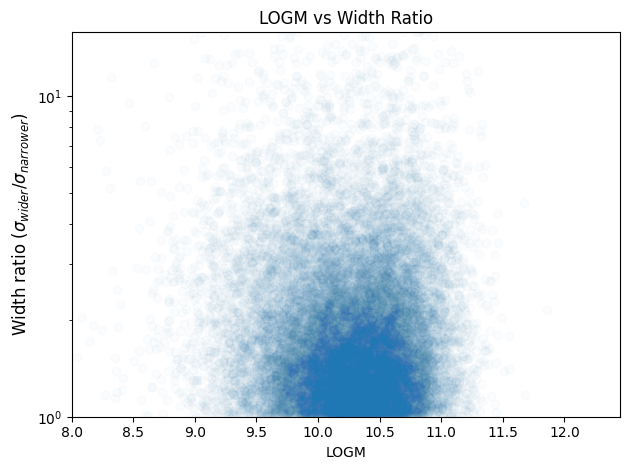

In [12]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['LOGM'], 10**np.abs(np.log10(dps_df['width_ratio'])), alpha=0.02)
plt.xlim(left=8)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('LOGM')
plt.ylabel(r'Width ratio ($\sigma_{wider}/\sigma_{narrower}$)', fontsize=12)
plt.title('LOGM vs Width Ratio')
plt.tight_layout()
plt.show()

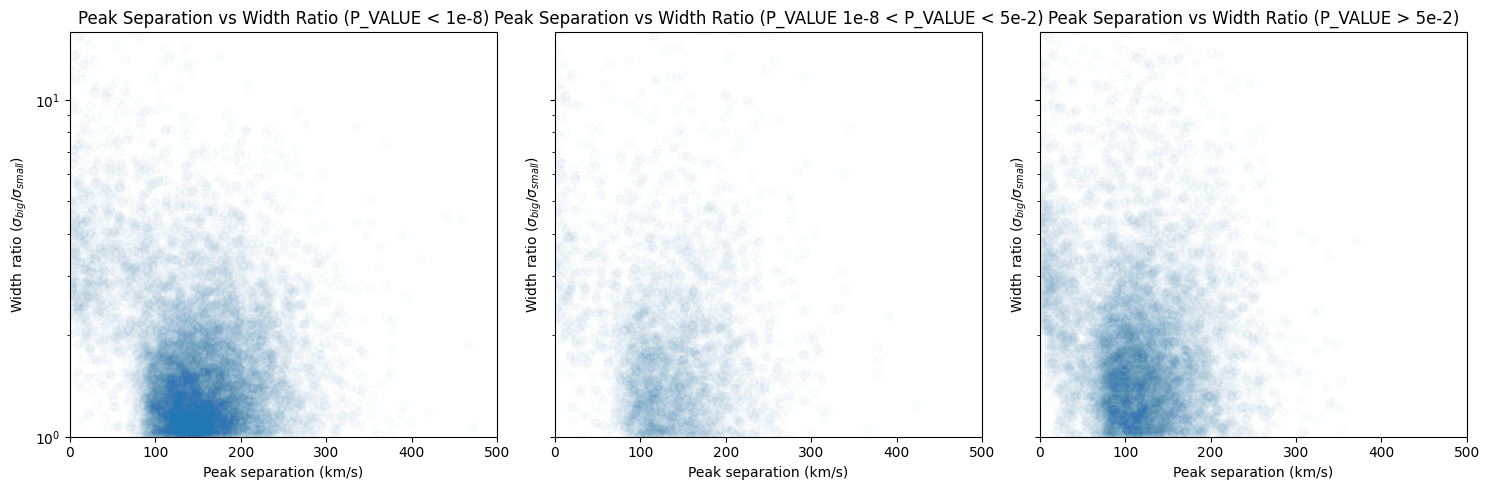

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, df in enumerate([dps_df[dps_df['P_VALUE']<1e-8], dps_df[(dps_df['P_VALUE']>1e-8)&(dps_df['P_VALUE']<1e-5)], dps_df[dps_df['P_VALUE']>1e-5]]):
    ax[i].scatter(df['delta_dv'], 10**np.abs(np.log10(df['width_ratio'])), alpha=0.02)
    ax[i].set_xlim(left=0, right=500)
    ax[i].set_ylim(bottom=1, top=10**1.2)
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Peak separation (km/s)')
    ax[i].set_ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
    ax[i].set_title(f'Peak Separation vs Width Ratio (P_VALUE {["< 1e-8", "1e-8 < P_VALUE < 5e-2", "> 5e-2"][i]})')
plt.tight_layout()
plt.show()

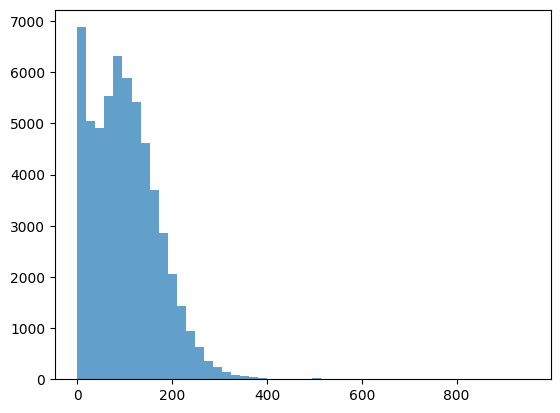

In [14]:
plt.hist(all_df['delta_dv'], bins=50, alpha=0.7)
plt.show()

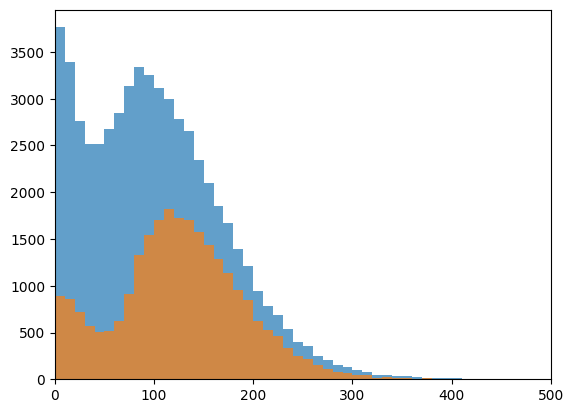

In [15]:
plt.hist(all_df['delta_dv'], bins=50, alpha=0.7, density=False, range=(0, 500))
plt.hist(dps_df['delta_dv'], bins=50, alpha=0.7, density=False, range=(0, 500))
plt.xlim(left=0, right=500)
plt.show()

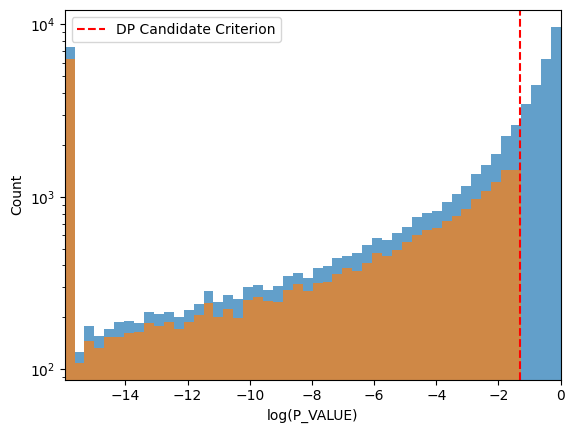

In [16]:
plt.hist(np.log10(all_df['P_VALUE']), bins=50, alpha=0.7, range=(np.min(np.log10(all_df['P_VALUE'])), 0))
plt.hist(np.log10(dps_df['P_VALUE']), bins=50, alpha=0.7, range=(np.min(np.log10(all_df['P_VALUE'])), 0))
plt.axvline(x=np.log10(5e-2), color='r', linestyle='--', label='DP Candidate Criterion')
plt.xlim((np.min(np.log10(all_df['P_VALUE'])), 0))
plt.yscale('log')
plt.ylabel('Count')
plt.xlabel('log(P_VALUE)')
plt.legend()
plt.show()

In [17]:
wider_sigma = dps_df.apply(lambda row: max(row['SIGMA_R'], row['SIGMA_L']), axis=1)
narrower_sigma = dps_df.apply(lambda row: min(row['SIGMA_R'], row['SIGMA_L']), axis=1)

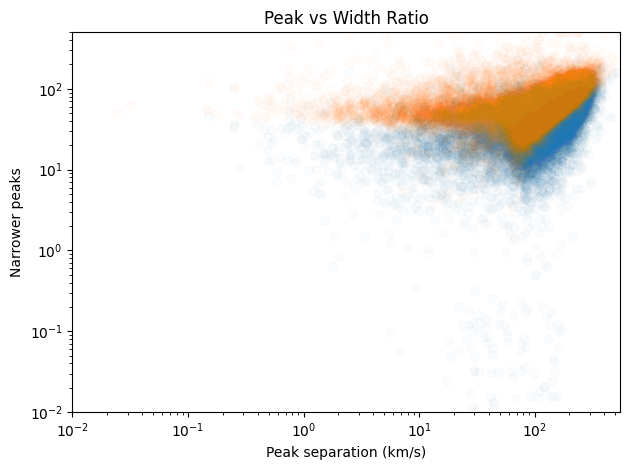

In [18]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], narrower_sigma, alpha=0.02)
plt.scatter(dps_df['delta_dv'], wider_sigma, alpha=0.02)
plt.xlim(left=1e-2)
plt.ylim(bottom=1e-2, top=5e2)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Narrower peaks')
plt.title('Peak vs Width Ratio')
plt.tight_layout()
plt.show()

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89316/690484117.py:4: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(left=0)
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89316/690484117.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0)


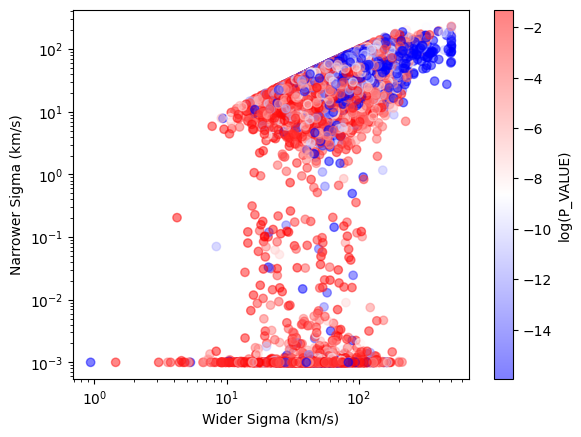

In [23]:
sc = plt.scatter(wider_sigma, narrower_sigma, c=np.log10(dps_df['P_VALUE']), alpha=0.5, cmap='bwr')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel('Wider Sigma (km/s)')
plt.ylabel('Narrower Sigma (km/s)')
cbar = plt.colorbar(sc)
cbar.set_label('log(P_VALUE)')

plt.show()

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89316/2008932658.py:4: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(left=0)
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89316/2008932658.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0)


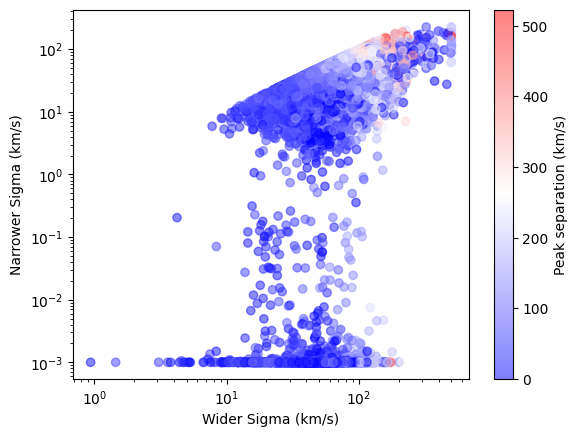

In [37]:
sc = plt.scatter(wider_sigma, narrower_sigma, c=dps_df['delta_dv'], alpha=0.5, cmap='bwr')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel('Wider Sigma (km/s)')
plt.ylabel('Narrower Sigma (km/s)')
cbar = plt.colorbar(sc)
cbar.set_label('Peak separation (km/s)')

plt.show()

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89316/2290350889.py:4: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(left=0)
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89316/2290350889.py:5: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0)


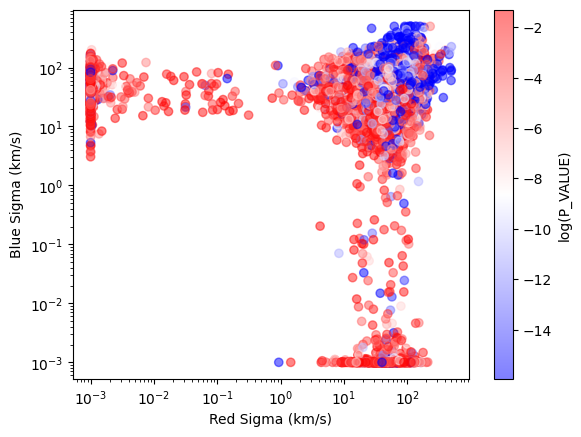

In [24]:
sc = plt.scatter(dps_df['SIGMA_R'], dps_df['SIGMA_L'], c=np.log10(dps_df['P_VALUE']), alpha=0.5, cmap='bwr')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.xlabel('Red Sigma (km/s)')
plt.ylabel('Blue Sigma (km/s)')
cbar = plt.colorbar(sc)
cbar.set_label('log(P_VALUE)')

plt.show()

In [20]:
dps_df['wider_sigma'] = dps_df.apply(lambda row: max(row['SIGMA_R'], row['SIGMA_L']), axis=1)
dps_df['narrower_sigma'] = dps_df.apply(lambda row: min(row['SIGMA_R'], row['SIGMA_L']), axis=1)

In [21]:
dps_df[(dps_df['narrower_sigma']<1e-2)&(dps_df['BPT_2COMP']!=512)&(dps_df['dp_count']!=1)].sort_values(by='delta_dv', ascending=False).head(50)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count,delta_dv,width_ratio,wider_sigma,narrower_sigma
17228,39627794363187268,214.251465,0.142429,0.134220,10.615790,0.833282,12.456516,-2.086230e+02,98.154617,0.001000,...,1,1,2,0.649406,0.644079,2,221.079559,0.000010,98.154617,0.001000
23051,39627817914208774,178.245926,1.306892,0.196915,10.935195,0.989349,27.386354,-1.355056e+02,106.497177,0.001000,...,4,1,5,0.576525,0.390477,2,162.891998,0.000009,106.497177,0.001000
14072,39627787744579122,179.910828,-0.074724,0.173925,10.179785,-0.248728,158.718063,-1.711130e-14,0.001201,87.326370,...,16,16,32,-0.469621,-0.790004,2,158.718063,72737.085938,87.326370,0.001201
18111,39627800012919109,191.214508,0.389008,0.079789,10.384574,0.261385,121.282761,-2.795154e+01,0.001000,128.155289,...,16,16,32,-0.289224,-0.350108,4,149.234299,128155.234375,128.155289,0.001000
22293,39627812344172044,206.150909,0.959673,0.164888,10.185042,0.600949,21.172350,-1.131153e+02,86.244728,0.001000,...,1,1,2,0.490183,0.412338,2,134.287659,0.000012,86.244728,0.001000
1616,39627745747010390,196.542297,-1.849688,0.091020,10.062546,-8.165605,101.689949,-3.257410e+01,0.001000,67.567871,...,4,1,5,-0.746137,-1.218732,2,134.264053,67566.265625,67.567871,0.001000
1457,39627745675706500,192.254852,-1.838995,0.084379,10.308319,-3.656238,111.662277,-2.153297e+01,0.001001,55.002022,...,4,16,20,-0.836096,-1.356401,2,133.195251,54959.703125,55.002022,0.001001
25063,39627824176300422,191.271652,1.414996,0.137862,9.867755,0.522259,27.432644,-1.009575e+02,79.827415,0.008983,...,1,1,2,0.298341,0.208045,2,128.390182,0.000113,79.827415,0.008983
5072,39627757763693355,192.877914,-1.221710,0.284611,10.373133,0.210044,100.901413,-2.367581e+01,0.001001,69.640198,...,1,4,5,0.819806,0.498703,2,124.577225,69579.867188,69.640198,0.001001
10872,39627775916642046,194.917084,-0.602356,0.106498,10.055657,-0.413765,105.763763,-1.861364e+01,0.001041,68.160446,...,1,1,2,-0.292912,-0.310712,2,124.377396,65447.718750,68.160446,0.001041


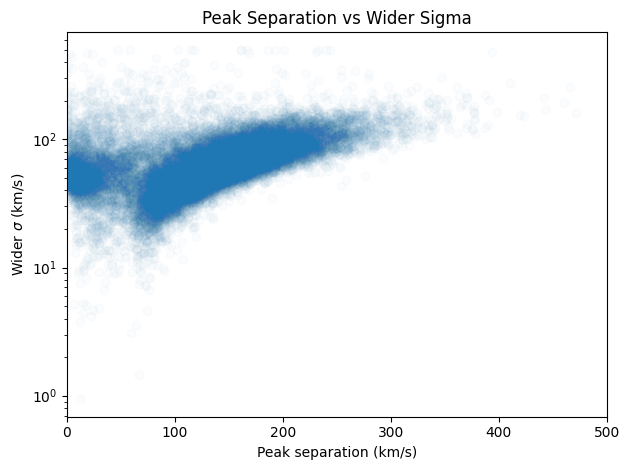

In [32]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], wider_sigma, alpha=0.02)
plt.xlim(left=0, right=500)
# plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Wider $\sigma$ (km/s)')
plt.title('Peak Separation vs Wider Sigma')
plt.tight_layout()
plt.savefig('./figures/Mar26/peak_sep_wider_sigma.png')
plt.show()

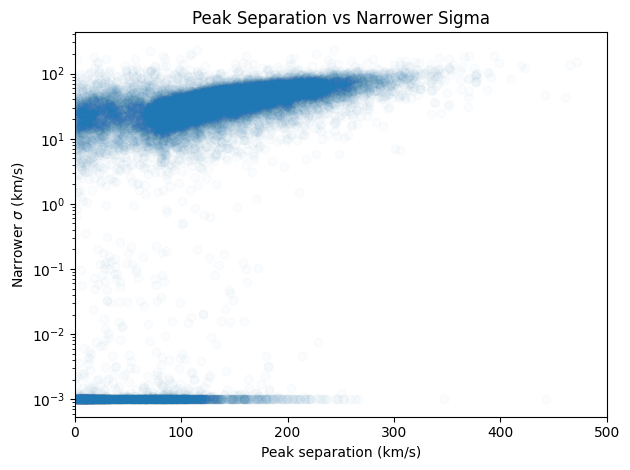

In [33]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], narrower_sigma, alpha=0.02)
plt.xlim(left=0, right=500)
# plt.ylim(bottom=1)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Narrower $\sigma$ (km/s)')
plt.title('Peak Separation vs Narrower Sigma')
plt.tight_layout()
plt.savefig('./figures/Mar26/peak_sep_narrower_sigma.png')
plt.show()